Tập mờ C (lớn tuổi):
  μ_C(    1) = 0.0
  μ_C(   14) = 0.0
  μ_C(   25) = 0.0
  μ_C(   40) = 0.5
  μ_C(   60) = 1.0
  μ_C(  100) = 1.0

Tập mờ D (đi lại chậm chạp):
  μ_D(    1) = 0.0
  μ_D(    5) = 0.5
  μ_D(   10) = 1.0

Tập mờ G = C × D ("già thật sự") trên X × Y:
  0.0 / (  1,  1)
  0.0 / (  1,  5)
  0.0 / (  1, 10)
------------------------------
  0.0 / ( 14,  1)
  0.0 / ( 14,  5)
  0.0 / ( 14, 10)
------------------------------
  0.0 / ( 25,  1)
  0.0 / ( 25,  5)
  0.0 / ( 25, 10)
------------------------------
  0.0 / ( 40,  1)
  0.5 / ( 40,  5)
  0.5 / ( 40, 10)
------------------------------
  0.0 / ( 60,  1)
  0.5 / ( 60,  5)
  1.0 / ( 60, 10)
------------------------------
  0.0 / (100,  1)
  0.5 / (100,  5)
  1.0 / (100, 10)
------------------------------


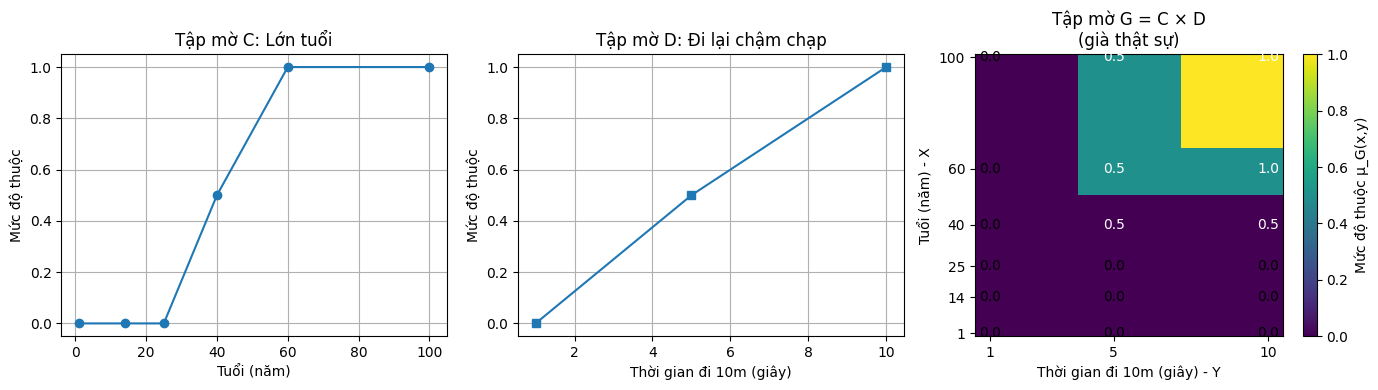

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =======================
# 1. DỮ LIỆU VÍ DỤ 4
# =======================

# Không gian nền tuổi
X = np.array([1, 14, 25, 40, 60, 100], dtype=float)

# Tập mờ "lớn tuổi" C:
# C = { 0/1, 0/14, 0/25, 0.5/40, 1/60, 1/100 }
mu_C = np.array([0.0, 0.0, 0.0, 0.5, 1.0, 1.0])

# Không gian nền thời gian đi 10m (giây)
Y = np.array([1, 5, 10], dtype=float)

# Tập mờ "đi lại chậm chạp" D:
# D = { 0/1, 0.5/5, 1/10 }
mu_D = np.array([0.0, 0.5, 1.0])

# =======================
# 2. TẬP MỜ GIÀ THẬT SỰ G = C × D
#    μ_G(x,y) = min( μ_C(x), μ_D(y) )
# =======================

G = np.minimum(mu_C[:, None], mu_D[None, :])  # ma trận 6x3

# =======================
# 3. IN KẾT QUẢ
# =======================

print("Tập mờ C (lớn tuổi):")
for x, c in zip(X, mu_C):
    print(f"  μ_C({x:5.0f}) = {c}")

print("\nTập mờ D (đi lại chậm chạp):")
for y, d in zip(Y, mu_D):
    print(f"  μ_D({y:5.0f}) = {d}")

print("\nTập mờ G = C × D (\"già thật sự\") trên X × Y:")
for i, x in enumerate(X):
    for j, y in enumerate(Y):
        print(f"  {G[i, j]:3.1f} / ({x:3.0f}, {y:2.0f})")
    print("-" * 30)

# =======================
# 4. VẼ HÌNH MINH HỌA
# =======================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- 4.1. Tập mờ C (lớn tuổi) ---
ax = axes[0]
ax.plot(X, mu_C, marker='o')
ax.set_title("Tập mờ C: Lớn tuổi")
ax.set_xlabel("Tuổi (năm)")
ax.set_ylabel("Mức độ thuộc")
ax.set_ylim(-0.05, 1.05)
ax.grid(True)

# --- 4.2. Tập mờ D (đi lại chậm chạp) ---
ax = axes[1]
ax.plot(Y, mu_D, marker='s')
ax.set_title("Tập mờ D: Đi lại chậm chạp")
ax.set_xlabel("Thời gian đi 10m (giây)")
ax.set_ylabel("Mức độ thuộc")
ax.set_ylim(-0.05, 1.05)
ax.grid(True)

# --- 4.3. Heatmap cho G = C × D ---
ax = axes[2]
im = ax.imshow(G, origin='lower', cmap='viridis',
               extent=[Y[0]-0.5, Y[-1]+0.5, X[0]-1, X[-1]+1],
               aspect='auto')

ax.set_title("Tập mờ G = C × D\n(già thật sự)")
ax.set_xlabel("Thời gian đi 10m (giây) - Y")
ax.set_ylabel("Tuổi (năm) - X")

# gắn tick đúng theo giá trị X, Y
ax.set_xticks(Y)
ax.set_yticks(X)

# thêm giá trị μ lên từng ô cho dễ quan sát
for i, x in enumerate(X):
    for j, y in enumerate(Y):
        ax.text(y, x, f"{G[i,j]:.1f}",
                ha='center', va='center', color='white' if G[i,j] > 0.4 else 'black')

fig.colorbar(im, ax=ax, label='Mức độ thuộc μ_G(x,y)')
plt.tight_layout()
plt.show()


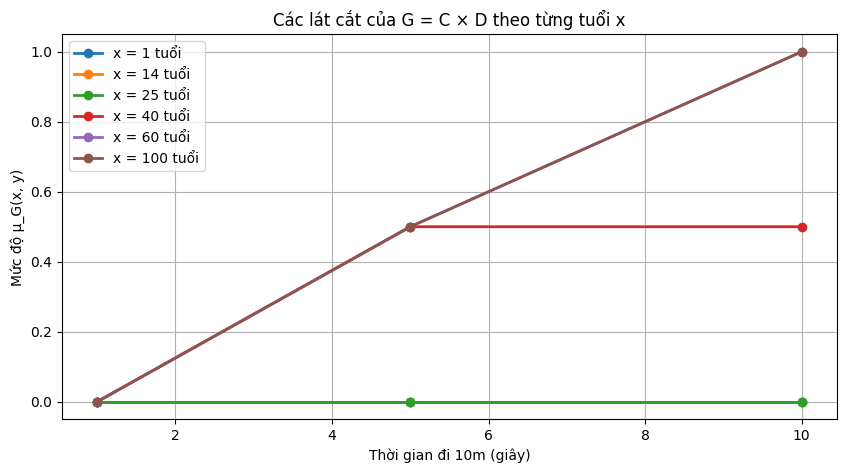

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Dữ liệu
X = np.array([1, 14, 25, 40, 60, 100])
mu_C = np.array([0.0, 0.0, 0.0, 0.5, 1.0, 1.0])

Y = np.array([1, 5, 10])
mu_D = np.array([0.0, 0.5, 1.0])

G = np.minimum(mu_C[:,None], mu_D[None,:])

plt.figure(figsize=(10,5))
for i, x in enumerate(X):
    plt.plot(Y, G[i], marker='o', linewidth=2, label=f"x = {x} tuổi")

plt.title("Các lát cắt của G = C × D theo từng tuổi x")
plt.xlabel("Thời gian đi 10m (giây)")
plt.ylabel("Mức độ μ_G(x, y)")
plt.grid(True)
plt.legend()
plt.show()


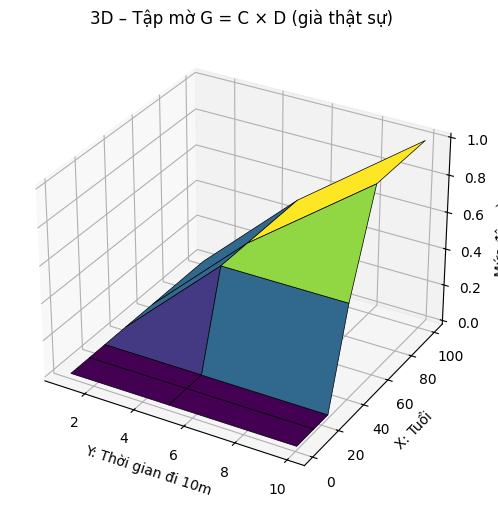

In [3]:
from mpl_toolkits.mplot3d import Axes3D

Xg, Yg = np.meshgrid(Y, X)  # đảo vì X: 6 giá trị, Y: 3 giá trị

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Xg, Yg, G, cmap='viridis', edgecolor='k', linewidth=0.5)

ax.set_title("3D – Tập mờ G = C × D (già thật sự)")
ax.set_xlabel("Y: Thời gian đi 10m")
ax.set_ylabel("X: Tuổi")
ax.set_zlabel("Mức độ mờ μ_G")
plt.show()


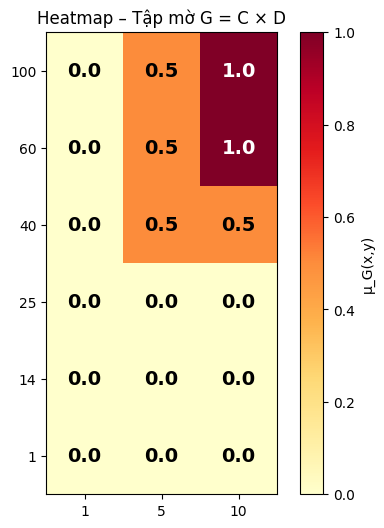

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(G, cmap="YlOrRd", origin="lower")
plt.colorbar(label="μ_G(x,y)")
plt.xticks(range(len(Y)), Y)
plt.yticks(range(len(X)), X)
plt.title("Heatmap – Tập mờ G = C × D")

# Hiển thị giá trị μ ngay trên ô
for i in range(len(X)):
    for j in range(len(Y)):
        plt.text(j, i, f"{G[i,j]:.1f}", ha="center", va="center",
                 color="black" if G[i,j] < 0.6 else "white",
                 fontsize=14, fontweight='bold')

plt.show()
